In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib
from IPython.display import display, clear_output


import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import os
import json

import copy
import subprocess
import shutil

import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)


from visuals import *

from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
eps = 1.0e-6

diffmod = DifferentialModule()

# Set the device that we will create the BPS on

device = 'mps'

print(f"Using device: {device}")

['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: mps


In [2]:
#Read in a config file that specifies the settings for a BPS (e.g. the sdf, the coarse mesh file, the blend function, the polynomial degree)
#e.g. sphere100, torus100, camera200, spike



config_filepath = "configs/surfaces/mobius220.json"
config_filepath = "configs/surfaces/bob500.json"
config_filepath = "configs/surfaces/sphere100.json"

config_filepath = "configs/surfaces/urchin210.json"

#config_filepath = "configs/surfaces/bob500.json"



#config_filepath = "configs/surfaces/fertility300_no_posenc.json"

#config_filepath = "configs/surfaces/fertility500.json"

config_filepath = "configs/surfaces/mobius220.json"


with open(config_filepath, "r") as f:
    config_dict = json.load(f)
    namestring = stringify_config(config_dict)
    print('Namestring will be ', namestring)
    
    shape_name = config_dict['shape-name']
    surface_config = config_dict['surface-config']
    training_config = config_dict['training-config']





if 'sdf_weights_path' in training_config.keys():
    DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/' + training_config['sdf_weights_path'], device=device, posenc=posenc)
else:
    DEEPSDF_MODEL = None

if 'sdf_transition_width' in training_config.keys():
    transition_width = training_config['sdf_transition_width']
else:
    transition_width=0.0



Namestring will be  mobius___surf__=pou_trig__=mobius220-v7__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=1000__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F


In [3]:
visualise=True

In [4]:

import BPS
importlib.reload(BPS)
from BPS import BPS_fast

# instantiate
bps = BPS_fast( surface_config, device=device)

#bps.load_poly_coeffs('results/bob/best_pou_trig_coeffs.pth')
#bps.load_poly_coeffs('results/bob/best_pou_inv_exp_coeffs.pth')
#bps.load_poly_coeffs('results/bob/best_coeffs.pth')
#bps.load_poly_coeffs('results/urchin/best_coeffs.pth')






Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on mps
HalfEdgeTriangleMesh with 168 points and 660 half edges.
mean edge length tensor(0.2160, device='mps:0')
Using Local Scales
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
sharp edges obj []
sharp edges o3d []
sharp halfedges: []
Computing rotations.


In [5]:
print([i  for i in range(len(bps.onerings)) if len(bps.onerings[i]['V_indices'])==2])

[65, 130]


In [6]:
bps.do_mobius_edits()


'''
bps.rotations[65] = ( rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(two_pi/4 + two_pi/12) ).to(device) @

                     rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(-two_pi/6) ).to(device) @
                     rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(two_pi/2) ).to(device) @
    rotation_matrix_axis_angle(torch.tensor([1.0,0.0,0.0]).float(), torch.tensor(two_pi/2) ).to(device) @
                                                            rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(two_pi/3) ).to(device) @ bps.rotations[65])


bps.rotations[18] = ( rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(two_pi/4) ) .to(device) @
    rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(-two_pi/6) ) .to(device)  @
                     
                     rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[18]).float(), torch.tensor(-two_pi/12) ).to(device) @
    rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[18]).float(), torch.tensor(-two_pi/12) ).to(device)   @
                     rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[18]).float(), torch.tensor(two_pi/2) ).to(device) @
                      bps.rotations[18])

'''



                     

'\nbps.rotations[65] = ( rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(two_pi/4 + two_pi/12) ).to(device) @\n\n                     rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(-two_pi/6) ).to(device) @\n                     rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(two_pi/2) ).to(device) @\n    rotation_matrix_axis_angle(torch.tensor([1.0,0.0,0.0]).float(), torch.tensor(two_pi/2) ).to(device) @\n                                                            rotation_matrix_axis_angle(torch.tensor(bps.he_mesh.vertex_normals[65]).float(), torch.tensor(two_pi/3) ).to(device) @ bps.rotations[65])\n\n\nbps.rotations[18] = ( rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(two_pi/4) ) .to(device) @\n    rotation_matrix_axis_angle(torch.tensor([0.0,1.0,0.0]).float(), torch.tensor(-two_pi/6) ) .to(device)  @\n                     \n      

In [7]:
mesh = trimesh.Trimesh(vertices=bps.V.cpu().numpy(), faces=bps.V.cpu().numpy(), process=False)

# Optional: compute normals if needed
mesh.rezero()          # shift mesh to origin if desired
mesh.remove_duplicate_faces()
mesh.remove_degenerate_faces()
mesh.fix_normals()     # ensure normals are consistent

# Export to file
mesh.export('data/surfaces/mobius224.obj')   # can also use '.obj', '.stl', etc.
print("Saved mesh to mobius224.obj")

Saved mesh to mobius224.obj


/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_53821/2701610576.py:5: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  mesh.remove_duplicate_faces()
/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_53821/2701610576.py:6: DeprecationWarning: `remove_degenerate_faces` is deprecated and will be removed in March 2024 replace with `self.update_faces(self.nondegenerate_faces(height=height))`
  mesh.remove_degenerate_faces()


In [8]:
bps.onerings[21]

{'V_indices': [65, 28, 20, 18, 93, 129],
 'V_pos': [array([-1.00190032,  0.1249781 , -0.25386009]),
  array([-9.94112074e-01,  2.50800312e-01, -1.00000001e-07]),
  array([-1.02490354,  0.2579954 ,  0.2523877 ])],
 'triangles': [11, 104, 105, 202, 43, 42],
 'valence': 6,
 'cumulative_angles': None,
 'central_pos': array([-1.01768827e+00,  1.26271397e-01, -1.00000001e-07]),
 'sharp_halfedges': [],
 'is_boundary': True,
 'angle': 1.0471975511965976}

In [9]:
################# visualise BNS ##########################


if visualise==True:
    
    import visuals
    importlib.reload(visuals)
    from visuals import *
    
    import differential
    
    importlib.reload(differential)
    from differential import *
    
    import mesh_processing
    importlib.reload(mesh_processing)
    from mesh_processing import *
    
    
    vis_start_time = time.time()
    
    bps_visualiser = BPS_visualiser(bps, mesh_res=5, mobius_example=True)
    
    settings = ['one-colour', 'normals', 'angle', 'curv', 'default']
    settings = ['one-colour', 'normals']
    #settings = ['one-colour', 'normals', 'unblended']
    settings = ['blend', 'param', 'normals']
    settings = ['default', 'angle', 'normals', 'abs-normals']
    settings = ['default', 'one-colour']
    
    #settings = ['one-colour', 'curv']
    #settings = ['normals', 'angle', 'default', 'one-colour']
    #settings = ['angle', 'one-colour']
    #settings = ['unblended']
    #settings=['curv']
    #settings=['blend']
    
    bps_visualiser.compute_quantities(settings=settings)
    
    torch.mps.synchronize()
    vis_end_time = time.time()
    
    print('Vis took', vis_end_time - vis_start_time, 'seconds.')


Precomputing blend weights etc, using pou_trig blending.
Now deadling with poly basis
degree: 2
Vis took 3.7684359550476074 seconds.


In [10]:
if visualise==True:
    bps_visualiser.show_bps(settings=settings, show_on_coarse=False)
    


In [11]:
bps.F.shape

(220, 3)

In [12]:

samples_filename=None ### Do not load samples from a file because the precomputation will be different whenever settings change.
if samples_filename == None:

    subprocess.run(
    [
        "python", "precomputation.py",
        "--output-filepath", "data/precomputation_results/temp-samples.pth",
        "--config-filepath", config_filepath
    ],
    check=True
)
    precomputed_training_data = torch.load('data/precomputation_results/temp-samples.pth')

else:
    precomputed_training_data = torch.load(samples_filename)






'''
training_samples = bps.compute_samples(num_samples=training_config['num_samples_per_face'])
x = training_samples["uv"]

precomputed_training_data = bps.precompute_data_from_samples(
    x, detached=True
)
'''


print((precomputed_training_data['poly_basis_gradient']**2).sum())
print((precomputed_training_data['blend_weights_gradient']**2).sum())
print((precomputed_training_data['onering_coords_gradient']**2).sum())


print(precomputed_training_data['all_Jc_pinv'].shape)
print(precomputed_training_data['all_J_proxy'].shape)



['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: mps
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on mps
HalfEdgeTriangleMesh with 168 points and 660 half edges.
mean edge length tensor(0.2160, device='mps:0')
Using Local Scales
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
sharp edges obj []
sharp edges o3d []
sharp halfedges: []
Computing rotations.
Precomputing blend weights etc, using pou_trig blending.
Now deadling with poly basis
Saved precomputed samples to data/precomputation_results/temp-samples.pth


/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_53821/1690592532.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  precomputed_training_data = torch.load('data

tensor(1.1605e+08, device='mps:0')
tensor(nan, device='mps:0')
tensor(nan, device='mps:0')
torch.Size([220, 2, 3])
torch.Size([220, 2, 2])


In [13]:
print(precomputed_training_data['all_Jc_pinv'].shape)
print(precomputed_training_data['all_J_proxy'].shape)

print(bps.F.shape[0])

torch.Size([220, 2, 3])
torch.Size([220, 2, 2])
220


In [14]:
############### initial training settings #####################

epoch=0

losses=[]
pos_losses=[]
normals_regs=[]
distortion_regs=[]
bdry_losses=[]
fractional_epochs=[]


epochs=[]
times=[]
num_patches = bps.num_facepatches

loss=99999







#lr = 0.001
#optimizer = torch.optim.AdamW(bps.parameters(), lr=lr)
#optimizer = torch.optim.SGD(bps.parameters(), lr=initial_lr, momentum=0.9)

In [122]:
def save_epoch_artifacts(
    out_dir,
    epoch,
    fig,
    info_str
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # ---- save plot ----
    plot_path = out_dir / f"epoch_{epoch:05d}.png"
    if fig is not None:
        fig.savefig(plot_path, dpi=150)
        plt.close(fig)

    # ---- save text ----
    txt_path = out_dir / f"epoch_{epoch:05d}.txt"
    with open(txt_path, "w") as f:
        f.write(info_str)




def train_batch_loop(
    lr=0.01,
    batch_size=10,
    min_loss=0.0005,
    normals_reg_coeff=0.0,
    distortion_reg_coeff=0.0,
    bdry_loss_coeff=0.0,
    batch_print_rate=100,
    batch_plot_rate=10,
    epoch_print_rate=1,
    epoch_save_rate=1,
    epoch_plot_rate=1,
    plot=False,
    flag='poly',
    just_onering=False,
    degree=3,
    max_epochs=1000,
    verify_gradient=False,
    area_weighting=False,
    debug_ptcloud=False
):
    global optimizer, scheduler, losses, pos_losses, normals_regs, distortion_regs
    global times, fractional_epochs, epoch, loss, num_patches, eps, sdf_id
    global lrs  # <-- ADDED FOR LEARNING RATE HISTORY

    # Ensure lr list exists
    try:
        lrs
    except NameError:
        lrs = []

    if degree is None:
        degree = bps.degree

    if degree > bps.degree:
        raise ValueError(
            f"Sorry, this BPS supports only degree {bps.degree} (requested degree {degree})."
        )

    if distortion_reg_coeff > 0.0 or normals_reg_coeff > 0.0 or area_weighting==True:
        compute_jacobian=True
    else:
        compute_jacobian=False

    # Patch selection
    if just_onering:
        select_patch_indices = torch.tensor(
            bps.onerings[0]['triangles'], dtype=torch.long, device=bps.device
        )
    else:
        select_patch_indices = torch.arange(
            bps.F.shape[0], dtype=torch.long, device=bps.device
        )

    seqs = bps.F.shape[0]
    total_num_points = precomputed_training_data['equilateral_triangle_samples'].shape[1]





    def get_mesh_boundary_edges(faces):
        """
        Finds all boundary edges in a triangle mesh.
        Returns a dictionary matching the required format:
        { edge_id: {'face_index': int, 'in_face_bdry_edge_index': int} }
        """
        
        edge_counts = {}
        edge_info = {}
        
        for f_idx, face in enumerate(faces):
            # Define the 3 directed edges of the triangle
            edges = [
                (face[0], face[1]), # in_face_bdry_edge_index: 0
                (face[1], face[2]), # in_face_bdry_edge_index: 1
                (face[2], face[0])  # in_face_bdry_edge_index: 2
            ]


            
            for e_idx, edge in enumerate(edges):
                # Sort the vertex indices so (v1, v2) and (v2, v1) map to the same undirected edge
                u_edge = tuple(sorted(edge))
                
                if u_edge in edge_counts:
                    edge_counts[u_edge] += 1
                else:
                    edge_counts[u_edge] = 1
                    # Save the face and edge index where we first saw this edge
                    edge_info[u_edge] = {
                        'face_index': f_idx, 
                        'in_face_bdry_edge_index': e_idx
                    }
                    
        # Filter for edges that appear exactly once (these are the naked boundaries)
        bdry_edges = {}
        bdry_counter = 0
        
        for u_edge, count in edge_counts.items():
            if count == 1:
                bdry_edges[bdry_counter] = edge_info[u_edge]
                bdry_counter += 1
                
        return bdry_edges



    

    '''
    bdry_edges = {0 : {'face_index': 0, 'in_face_bdry_edge_index': 0},
                 1 : {'face_index': 2, 'in_face_bdry_edge_index': 2},
                 2 : {'face_index': 5, 'in_face_bdry_edge_index': 1}}
    '''

    # 1. Before the batch loop, define your ranges
    num_interior = training_config['num_samples_per_face']
    num_bdry = 3 * training_config['num_bdry_samples_per_edge']
    num_total = num_interior + num_bdry

    # Dynamically extract the boundary edges based on the coarse mesh topology
    # Assuming bps.F contains your (N, 3) face tensor
    bdry_edges = get_mesh_boundary_edges(bps.F)
    
    print(f"Detected {len(bdry_edges)} boundary edges in the coarse mesh.")


    


    start_time = time.time()

    # ---- begin epochs ----
    while loss > min_loss and epoch < max_epochs:

        #perm = torch.randperm(total_num_points)


        # 2. Inside the 'while' loop, create TWO permutations
        perm_int = torch.randperm(num_interior)
        #perm_bdry = torch.arange(num_bdry) + num_interior
        idx_bdry = torch.arange(num_bdry, device=bps.device) + num_interior

        precomputed_batch_data_bdry = bps.get_batch(precomputed_training_data, idx_bdry)
        batch_t_bdry = precomputed_batch_data_bdry['equilateral_triangle_samples']



        #total_points_in_data = precomputed_training_data['equilateral_triangle_samples'].shape[1]
        #print(f"Total points in data: {total_points_in_data}")
        #print(f"num_interior: {num_interior}")
        #print(f"num_bdry: {num_bdry}")
        #print(f"Expected total: {num_interior + num_bdry}")

        #plt.scatter(batch_t_bdry[0,:,0].detach().cpu().numpy(), batch_t_bdry[0,:,1].detach().cpu().numpy())
        #plt.show()

        
        
        # 3. Calculate batch sizes proportionally (optional) or just use the same i
        # For simplicity, let's assume you want to maintain the ratio in every batch:
        batch_size_int = int(batch_size * (num_interior / num_total))

        

        
        epoch_loss = 0.0

        last_fig = None
        last_info_str = ""

        # ---- batches ----
        for i_int in range(0, num_interior, batch_size_int):

            i = i_int + len(idx_bdry)

            # ======================================================
            # TRUE GET-DATA TIME
            # ======================================================
            get_t0 = time.time()



            ############ FIX THIS!!!
            #idx = perm[i:i + batch_size]
            idx_int = perm_int[i_int : i_int + batch_size_int]



            
            optimizer.zero_grad()

            precomputed_batch_data = bps.get_batch(precomputed_training_data, idx_int)
            batch_t = precomputed_batch_data['equilateral_triangle_samples']
            
            

            #batch_t = precomputed_training_data['equilateral_triangle_samples'][:, idx, :].detach().clone()
            #precomputed_batch_data = bps.precompute_data_from_samples(batch_t, detached=False)


            if compute_jacobian:
                for k in ['blend_weights', 'onering_coords', 'poly_basis']:
                    precomputed_batch_data[k] = (
                        precomputed_batch_data[k]
                        .detach()
                        .clone()
                        .requires_grad_(True)
                    )
                

            torch.mps.synchronize()
            get_data_time = time.time() - get_t0


            # ======================================================
            # TRUE FORWARD TIME
            # ======================================================
            torch.mps.synchronize()
            fwd_t0 = time.time()

            output_train = bps(precomputed_batch_data, degree=degree)
            output_train_bdry = bps(precomputed_batch_data_bdry, degree=degree)
            

           
            




            torch.mps.synchronize()
            fwd_time = time.time() - fwd_t0


            # ======================================================
            # LOSS COMPUTATION
            # ======================================================
            selected_pts = output_train[select_patch_indices, :, :].to(device)
            cur_sdf = sdf(
                selected_pts.reshape(1, -1, 3),
                training_config['sdf_id'],
                squared=False,
                model=DEEPSDF_MODEL,
                transition_width=transition_width
            )
            cur_udf = cur_sdf.abs()


            

            all_triangle_bdry_pts = output_train_bdry[:, :, :].to(device)
    
            cur_bdry_udf = sdf(
                all_triangle_bdry_pts.reshape(1, -1, 3),
                'mobius_bdry',
                squared=False,
                model=DEEPSDF_MODEL,
                transition_width=transition_width
            ).abs().reshape(all_triangle_bdry_pts.shape[0], all_triangle_bdry_pts.shape[1])

            all_relevant_bdry_udf = []
            all_shape_bdry_pts = []
            for edge_index in bdry_edges.keys():
                face_index = bdry_edges[edge_index]['face_index']
                in_face_bdry_edge_index = bdry_edges[edge_index]['in_face_bdry_edge_index']

                
                all_relevant_bdry_udf.append(cur_bdry_udf[face_index, 
                                          in_face_bdry_edge_index * num_bdry//3 : (in_face_bdry_edge_index+1) * num_bdry//3  ])

                #print('atbp shape', all_triangle_bdry_pts.shape)
                
                
                all_shape_bdry_pts.append(all_triangle_bdry_pts[face_index, 
                                          in_face_bdry_edge_index * num_bdry//3 : (in_face_bdry_edge_index+1) * num_bdry//3 , : ])

                

            all_relevant_bdry_udf = torch.stack(all_relevant_bdry_udf)
            #all_relevant_bdry_udf = cur_bdry_udf
            all_shape_bdry_pts = torch.stack(all_shape_bdry_pts)
            #all_shape_bdry_pts = all_triangle_bdry_pts
            

            if debug_ptcloud==True:
                # ================= SIMPLE DEBUG POPUP =================



                print(output_train.shape)
                # Flatten to (N, 3) and move to CPU
                pts_np = output_train[select_patch_indices, :, :].detach().cpu().reshape(-1, 3).numpy()
                pcd_debug = o3d.geometry.PointCloud()
                pcd_debug.points = o3d.utility.Vector3dVector(pts_np)
                pcd_debug.paint_uniform_color([0.0, 0.0, 1.0])


                #pts_np_bdry = output_train_bdry[select_patch_indices, :, :].detach().cpu().reshape(-1, 3).numpy()
                pts_np_bdry = all_shape_bdry_pts.detach().cpu().reshape(-1, 3).numpy()
                
                
                
                pcd_debug_bdry = o3d.geometry.PointCloud()
                pcd_debug_bdry.points = o3d.utility.Vector3dVector(pts_np_bdry)
                pcd_debug_bdry.paint_uniform_color([1.0, 0.0, 0.0])

                
                
                print("Opening debug window... Close it to resume training.")
                o3d.visualization.draw_geometries([pcd_debug, pcd_debug_bdry])
                #o3d.visualization.draw_geometries([pcd_debug])
                o3d.visualization.draw_geometries([pcd_debug_bdry])
                # ======================================================
                '''
                if np.isnan(pts_np_bdry).any():
                    pcd_debug.paint_uniform_color([1.0, 0.0, 0.0])
                else:
                    pcd_debug.paint_uniform_color([0.0, 1.0, 0.0])
                o3d.visualization.draw_geometries([pcd_debug])
                print(pts_np_bdry)
                '''


                 


            # Normals / distortion regularization
            if compute_jacobian==True:   ## 


                J_proxy = precomputed_batch_data['all_J_proxy']
                Jc_pinv = precomputed_batch_data['all_Jc_pinv']


                #print('gradient via blend')
                grad_via_blend = diffmod.gradient(out = output_train, wrt = precomputed_batch_data['blend_weights']) @ precomputed_batch_data['blend_weights_gradient']
                #print('grad blend', grad_via_blend.shape)

                

                d_out_d_poly = diffmod.gradient(out = output_train, wrt = precomputed_batch_data['poly_basis'])
                d_poly_d_oc = precomputed_batch_data['poly_basis_gradient']
                d_oc_dx = precomputed_batch_data['onering_coords_gradient']


            


                #print('d-out-d-poly, d-poly-d-oc, d-oc-dx', d_out_d_poly.shape, d_poly_d_oc.shape, d_oc_dx.shape)

                #grad_via_poly1 = torch.einsum('fbAsR, fbsRx, fsArx -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian1 = grad_via_blend + grad_via_poly1

                #grad_via_poly2 = torch.einsum('fbRsA, fbsRx, fsArx -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian2 = grad_via_blend + grad_via_poly2

                #grad_via_poly3 = torch.einsum('fbAsR, fbsRx, fsAxr -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian3 = grad_via_blend + grad_via_poly3

                grad_via_poly4 = torch.einsum('fbRsA, fbsRx, fsAxr -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                jacobian4 = grad_via_blend + grad_via_poly4
                

               
                ####################### TEST ONLY!!! #####################

                if verify_gradient:
                    cur_x = precomputed_batch_data['equilateral_triangle_samples'].detach()
                    cur_x.requires_grad=True
                    batch_data_with_tracked_gradients = bps.precompute_data_from_samples( cur_x, detached=False)
    
                    output_train_with_tracked_gradients = bps(batch_data_with_tracked_gradients, degree=degree)
    
                    autograd_jacobian = diffmod.gradient(out=output_train_with_tracked_gradients, wrt = cur_x)
    
                    for jacobian in [ jacobian4]:
                        print( 'difference between automatic and manual jacobians (sum of squared differences)', ((jacobian-autograd_jacobian)**2).sum() )
                        print('tensor sizes', jacobian.shape, autograd_jacobian.shape)
                        print('sum of squared values of each, for scale reference:')
                        print(((jacobian)**2).sum())
                        print(((autograd_jacobian)**2).sum())

                        diff = jacobian - autograd_jacobian

                        print("max abs:", diff.abs().max())
                        print("mean abs:", diff.abs().mean())
                        
                        print("relative max:",
                              (diff.abs() / (autograd_jacobian.abs() + 1e-12)).max())
                    
                    
                
                ######################################

                jacobian = jacobian4
                
                output_normals, jacobian = diffmod.compute_normals(
                    out=output_train,
                    wrt=batch_t,
                    jacobian = jacobian,
                    return_grad=True
                )

                


                #print('output_normals', output_normals)

            if normals_reg_coeff > 0.0:

                '''
                # This bugs. Do not use.
                grad_sdf = diffmod.gradient(
                    out=cur_sdf.unsqueeze(-1),
                    wrt=output_train
                ).squeeze()
                '''

                grad_sdf = torch.autograd.grad(
                    outputs=cur_sdf,
                    inputs=output_train,
                    grad_outputs=torch.ones_like(cur_sdf),
                    create_graph=False, #important that this is false.
                    retain_graph=True
                )[0]


                #####  grad_sdf = grad_sdf         / (grad_sdf.norm(dim=-1, keepdim=True) + 1e-4)
                
                normals_alignment = (output_normals * grad_sdf).sum(-1)    ##### .clamp(min=-1, max=1


                
                unscaled_local_normals_loss = (-torch.abs(normals_alignment) + 1.0)
                unscaled_normals_loss = unscaled_local_normals_loss.mean()
                normals_reg = normals_reg_coeff * unscaled_normals_loss
            else:
                normals_reg = torch.tensor(0.0, device=device)


            
           
            
            


            
            if distortion_reg_coeff > 0.0 or area_weighting==True:
                #I_E, I_F, I_G = diffmod.compute_FFF(
                #    out=output_train,
                #    wrt=batch_t,
                #    jacobian=jacobian,
                #    normals=output_normals )

                #print('jac, J_proxy, Jc_pinv', jacobian.shape, J_proxy.shape, Jc_pinv.shape)

                full_jacobian = jacobian @ J_proxy.unsqueeze(1) @ Jc_pinv.unsqueeze(1)    # chain rule

                
                
                M3 = full_jacobian.transpose(-1, -2) @ full_jacobian
                M2 = Jc_pinv.unsqueeze(1) @ M3 @ Jc_pinv.transpose(-1, -2).unsqueeze(1)  # (2×2)
                I_E, I_G, I_F = M2[:,:,0,0], M2[:,:,0,1], M2[:,:,1,1]
                
                trace = I_E + I_G
                det = I_E * I_G - I_F * I_F

            if distortion_reg_coeff > 0.0:    
                distortion_reg = distortion_reg_coeff * (trace + trace / (det + eps)).mean()
            else:
                distortion_reg = torch.tensor(0.0, device=device)

            if area_weighting==True:
                #print(cur_udf.shape, det.shape)

                w = det.reshape(-1) / ( det.mean() + eps)
                position_loss = (cur_udf*w).mean()
            else:
                position_loss = cur_udf.mean()

            if bdry_loss_coeff > 0.0:    
                bdry_loss = bdry_loss_coeff * all_relevant_bdry_udf.mean()
            else:
                bdry_loss = torch.tensor(0.0, device=device)
            


            
            

            batch_loss = position_loss + normals_reg + distortion_reg + bdry_loss

            # ---- accumulate real epoch loss ----
            epoch_loss += batch_loss.item() * batch_t.shape[1]

            # ======================================================
            # SCHEDULER STEP + RECORD LR
            # ======================================================
            
            current_lr = optimizer.param_groups[0]['lr']
            


            # ======================================================
            # TRUE BACKWARD TIME
            # ======================================================
            torch.mps.synchronize()
            bwd_t0 = time.time()

            batch_loss.backward()

            torch.mps.synchronize()
            bwd_time = time.time() - bwd_t0


            # ======================================================
            # TRUE OPT TIME
            # ======================================================
            torch.mps.synchronize()
            opt_t0 = time.time()

            optimizer.step()
            scheduler.step()

            torch.mps.synchronize()
            opt_time = time.time() - opt_t0


            # total batch time
            batch_time = get_data_time + fwd_time + bwd_time + opt_time


            # ---- logs ----
            times.append(batch_time)
            losses.append(batch_loss.item())
            pos_losses.append(position_loss.item())
            normals_regs.append(normals_reg.item())
            bdry_losses.append(bdry_loss.item())
            distortion_regs.append(distortion_reg.item())
            fractional_epochs.append(epoch + i / total_num_points)
            lrs.append(current_lr)


            # ======================================================
            # OPTIONAL PLOTTING (NOW 3 PANELS)
            # ======================================================
            if True: #(i // batch_size) % batch_plot_rate == 0 and plot:
                try:
                    plt.close(fig)
                except:
                    pass

                clear_output(wait=True)

                fig, axs = plt.subplots(3, 1, figsize=(10, 10))

                # ---- Panel 1: Loss ----
                axs[0].plot(fractional_epochs, np.log10(losses), label='loss')
                axs[0].plot(fractional_epochs, np.log10(pos_losses), label='pos loss')

                if normals_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(normals_regs), label='normals reg')

                if bdry_loss_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(bdry_losses), label='bdry loss')
                    
                if distortion_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(distortion_regs), label='distortion reg')

                axs[0].legend()
                axs[0].set_xlabel('Epoch')
                axs[0].set_ylabel('Log10 Loss')
                axs[0].set_title('Log10 Losses')

                axs[0].text(0.8, 0.9, f"Batch Loss: {batch_loss.item():.8f}",
                            transform=axs[0].transAxes,
                            ha='right', va='bottom')

                # ---- Panel 2: Timing ----
                axs[1].plot(fractional_epochs, times)
                axs[1].set_xlabel('Epoch')
                axs[1].set_title('True Batch Times')

                axs[1].text(0.98, 0.90, f"Batch Time: {batch_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.75, f"Fwd Time: {fwd_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.60, f"Bwd Time: {bwd_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.45, f"Get Data: {get_data_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.30, f"Opt Time: {opt_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')

                # ---- Panel 3: Learning Rate ----
                axs[2].plot(fractional_epochs, lrs)
                axs[2].set_xlabel('Epoch')
                axs[2].set_title('Learning Rate')
                axs[2].text(0.98, 0.85, f"LR: {current_lr:.6e}",
                            transform=axs[2].transAxes, ha='right')

                plt.tight_layout()
                display(fig)

                

                info_str = (
                    f"Epoch {epoch}\n"
                    f"Batch {i}\n"
                    f"Loss: {batch_loss:.8f}\n"
                    f"  pos:       {position_loss:.8f}\n"
                    f"  bdry:       {bdry_loss:.8f}\n"
                    f"  normals:   {normals_reg:.8f}\n"
                    f"  distort:   {distortion_reg:.8f}\n"
                    f"mean UDF: {cur_udf.mean():.8f}\n"
                    f"learning rate: {current_lr:.8f}\n"
                    f"\nTiming:\n"
                    f"  batch time {batch_time:.4f}s\n"
                    f"  fwd {fwd_time:.4f}s | bwd {bwd_time:.4f}s | "
                    f"data {get_data_time:.4f}s | opt {opt_time:.4f}s\n" )

                last_fig = fig
                last_info_str = info_str
                
                print(info_str)
    


        # ---- End of epoch ----
        loss = torch.tensor( epoch_loss / total_num_points )

        if epoch % epoch_print_rate == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.8f}")

        if epoch % epoch_save_rate == 0:
            ckpt_dir = results_dir 
        
            ckpt_path = ckpt_dir / f"epoch_{epoch:05d}.pth"
            bps.save_poly_coeffs(str(ckpt_path))
        
            save_epoch_artifacts( out_dir=ckpt_dir,epoch=epoch,fig=last_fig,info_str=last_info_str)
        
            print(f"Saved checkpoint + plot + log for epoch {epoch}.")

        epoch += 1
    end_time=time.time()
    
    print(f"Took {int((end_time-start_time)/60)}m {(end_time-start_time)%60:.2f}s")


In [123]:
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=1000, plot=True)

In [124]:
#train_batch_loop(lr=0.000000, degree=10, batch_size=10, min_loss=0.0006, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=1000, plot=True)

In [125]:
#train_batch_loop(lr=0.001, degree=2, batch_size=10, min_loss=0.0, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=1000, plot=True)

In [126]:
'''
initial_lr =1e-3
MIN_LR = 1e-5
max_epochs = 20
per_face_batch_size = 10
'''

# Training settings are specified in the config file.
initial_lr = training_config['initial_lr']
MIN_LR = training_config['min_lr']
max_epochs = training_config['max_epochs']
per_face_batch_size = training_config['per_face_batch_size']

area_weighting = training_config['area_weighting']
print(area_weighting)
distortion_reg_coeff = training_config['distortion_reg_coeff']
normals_reg_coeff = training_config['normals_reg_coeff']
bdry_loss_coeff = training_config['bdry_loss_coeff']

num_samples_per_face = training_config['num_samples_per_face']


# ======================================================
# OPTIMIZER
# ======================================================
optimizer = torch.optim.AdamW(bps.parameters(), lr=initial_lr)

# ======================================================
# FREEZE SELECTED ROWS OF THE PARAMETER (ADD THIS)
# ======================================================
# get the (168, 6, 3) parameter tensor
P = next(bps.parameters())



'''
# rows to freeze (CHANGE THESE INDICES)
fixed_rows = torch.tensor([65,21,18,94,93,129], device=P.device)

def freeze_rows_hook(grad):
    grad = grad.clone()
    grad[fixed_rows] = 0.0
    return grad

# register ONCE
P.register_hook(freeze_rows_hook)
'''

# ======================================================
# SCHEDULER
# ======================================================
T_max = (num_samples_per_face / per_face_batch_size) * max_epochs

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=T_max,
    eta_min=MIN_LR
)


False


In [127]:
bps.V.shape

torch.Size([168, 3])

In [128]:
for p in bps.parameters():
    print(type(p), p.shape, p.requires_grad)

<class 'torch.nn.parameter.Parameter'> torch.Size([168, 6, 3]) True


In [129]:
from datetime import datetime
from pathlib import Path

import shutil


# Build readable results name
results_namestring = (
    stringify_config(config_dict) 
    + "__"
    + datetime.now().strftime("%Y-%m-%d_%H-%M")
    
)


# Build directory path
results_dir = Path("results") / shape_name / results_namestring

# Create directories (no error if they already exist)
results_dir.mkdir(parents=True, exist_ok=True)



json.dump(config_dict, open(results_dir / "config.json", "w"), indent=2)




shutil.copy2('data/surfaces/'+surface_config['coarse_patches_id']+'.obj', results_dir / 'proxy.obj')





PosixPath('results/mobius/mobius___surf__=pou_trig__=mobius220-v7__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=1000__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F__2026-04-11_01-01/proxy.obj')

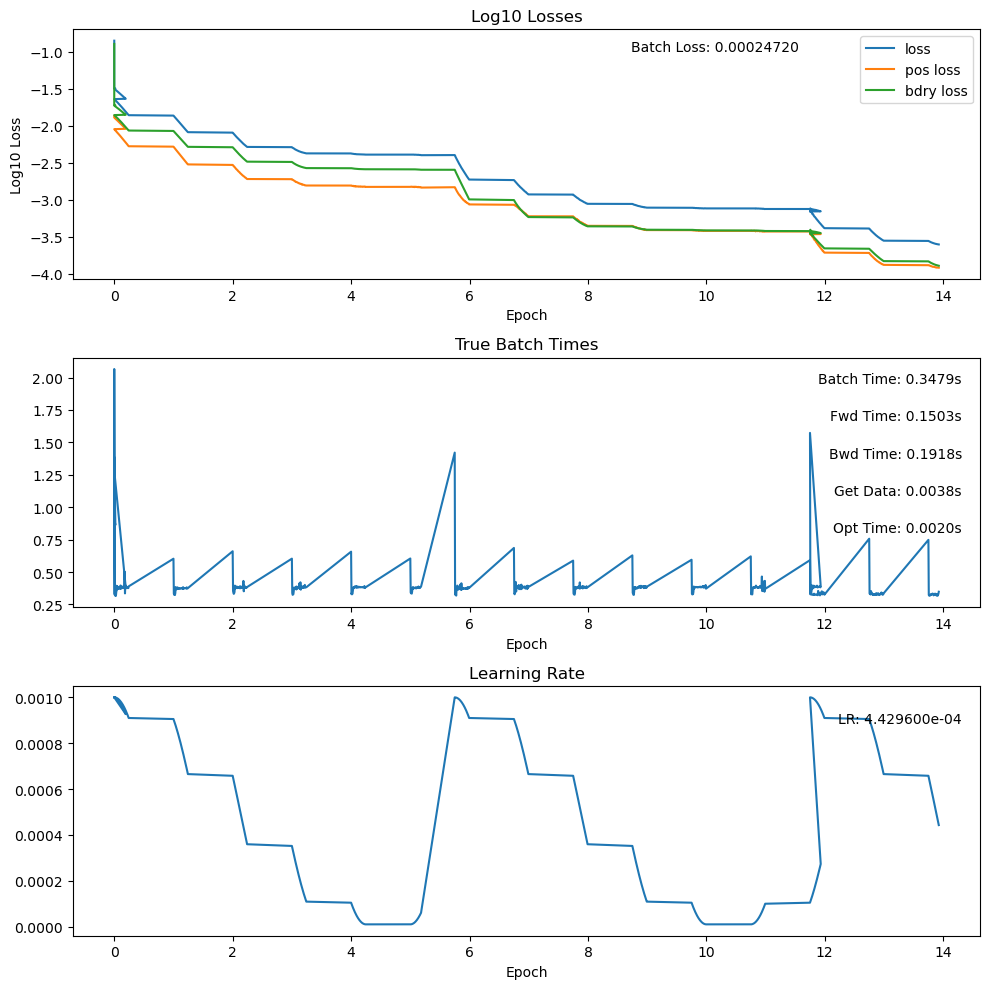

Epoch 13
Batch 37000
Loss: 0.00024720
  pos:       0.00011983
  bdry:       0.00012737
  normals:   0.00000000
  distort:   0.00000000
mean UDF: 0.00011983
learning rate: 0.00044296

Timing:
  batch time 0.3479s
  fwd 0.1503s | bwd 0.1918s | data 0.0038s | opt 0.0020s



KeyboardInterrupt: 

Error in callback <function flush_figures at 0x3187aa430> (for post_execute):



KeyboardInterrupt



In [130]:
train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size , min_loss=5e-5, debug_ptcloud=False, max_epochs=max_epochs, bdry_loss_coeff = bdry_loss_coeff, normals_reg_coeff = normals_reg_coeff, distortion_reg_coeff = distortion_reg_coeff, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=area_weighting)

In [ ]:
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.00000, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=False)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.000001, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)#
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True, verify_gradient=False)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.0, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)

In [131]:


# Save
bps.save_poly_coeffs(results_dir / "poly_coeffs.pth")
print(f"Saved polynomial coefficients to {results_dir}")

################ visualise bns ##################


# If you want indices from onerings
select_patch_indices = torch.tensor(
    bps.onerings[0]['triangles'], dtype=torch.long, device=bps.device
)

# If you want all triangle indices
select_patch_indices = torch.arange(
    bps.F.shape[0], dtype=torch.long, device=bps.device
)

import visuals
import importlib
importlib.reload(visuals)
from visuals import *

bps_visualiser = BPS_visualiser(bps, mesh_res=5, just_onering=False,
                               show_on_coarse=False, mobius_example=True)

settings = ['one-colour', 'default', 'normals', 'abs-normals']

bps_visualiser.compute_quantities(settings=settings)
bps_visualiser.show_bps(settings=settings, output_dir = results_dir)





Saved polynomial coefficients to results/mobius/mobius___surf__=pou_trig__=mobius220-v7__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=1000__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F__2026-04-11_01-01
Precomputing blend weights etc, using pou_trig blending.
Now deadling with poly basis
degree: 2
computing normals...


In [132]:
bps_visualiser.show_bps(settings=settings, output_dir = results_dir)



KeyboardInterrupt: 

In [ ]:
import visuals
import importlib
importlib.reload(visuals)
from visuals import *

bps_visualiser = BPS_visualiser(bps, mesh_res=6, test_flag='poly', just_onering=False, use_original_mesh=False,
                               show_on_coarse=False, mobius_example=True)

settings = ['one-colour', 'normals', 'angle']

bps_visualiser.compute_quantities(settings=settings)
bps_visualiser.show_bps(settings=settings, output_dir = results_dir, show_on_coarse=True)



In [ ]:
#bps_visualiser.show_implicit_error_on_pcd('deep3d_fruit')

In [ ]:
'''
import visuals
importlib.reload(visuals)
from visuals import *





############# Translating a Single Coarse Vertex ############
bns.reset()


T = torch.zeros_like(bns.V)
T[0,:] = torch.tensor([-0.1, +0.1, 0.0 ])

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()

'''

In [ ]:

'''
############# Perturbing Vertices ############
bns.reset()


T = torch.zeros_like(bns.V)
T += 0.01*torch.randn(bns.V.shape)

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()


'''

In [ ]:


'''
import visuals
importlib.reload(visuals)
from visuals import *

import implicit_reps
import importlib
importlib.reload(implicit_reps)
from implicit_reps import *

bps_visualiser = BPS_visualiser(bps, mesh_res=2, use_original_mesh=False,
                               show_on_coarse=False)

bps_visualiser.show_implicit_error_on_pcd(config_dict['shape_id'], num_samples=10000)
'''

In [ ]:

'''

for key in A.keys():
    print(key)
    #print( (A['equilateral_triangle_samples'] == B['equilateral_triangle_samples']).all() )
    print(A[key].requires_grad)


def check_view(t):
    return t._base is not None

for k, v in A.items():
    if torch.is_tensor(v):
        print(k, "is_view:", check_view(v))


def storage_ptr(t):
    return t.storage().data_ptr()

# gather grad-requiring tensors in your model
grad_tensors = []
for p in model.parameters():
    grad_tensors.append(p)

for k, v in A.items():
    if torch.is_tensor(v):
        for p in grad_tensors:
            if storage_ptr(v) == storage_ptr(p):
                print("ALIASES PARAM:", k)
'''

In [ ]:
A[]